In [ ]:
# -*- coding: utf-8 -*-

# Encoder vs. Decoder em Português: Fake News PT-BR

**Atividade:** comparar todos os modelos *encoder* da lista com todos os modelos *decoder* da lista em uma tarefa binária de fake news em português brasileiro.

**Dataset desta versão:** [`kauandivino/FakenewsBR`](https://huggingface.co/datasets/kauandivino/FakenewsBR). A tarefa é binária: classificar textos como notícia falsa ou notícia verdadeira. O notebook usa preferencialmente a coluna `text_clean`, quando disponível, e recua para outras colunas textuais caso necessário.

**Execução em loop:** primeiro percorre `ENCODER_MODEL_NAMES`, resetando a VRAM entre modelos e entre modos de fine-tuning; depois percorre `DECODER_MODEL_NAMES`, também resetando a VRAM entre decoders.

**Arquivo de resultados:** cada teste concluído grava uma linha em `resultados_encoder_decoder_fakenews_ptbr_loop.csv`, com `run_id`, modelo, papel, dataset, modo de treino, métricas, tempo, VRAM e quantidade de saídas inválidas do decoder.


In [ ]:
!pip install -q -U --force-reinstall pyarrow

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.5 which is incompatible.
dask-cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.5 which is incompatible.


In [ ]:
!pip install -q -U transformers datasets evaluate accelerate peft scikit-learn pandas matplotlib torchao

import gc
import time
import re
import random
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

from datasets import load_dataset
from sklearn.metrics import accuracy_score, f1_score, classification_report

print("CUDA disponível:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    total_vram = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f"VRAM total: {total_vram:.2f} GB")
else:
    print("Nenhuma GPU encontrada. Vá em Ambiente de execução > Alterar tipo de ambiente de execução > GPU (T4).")

def find_all_linear_names(model):
    """Detecta automaticamente os nomes dos módulos Linear para LoRA."""
    lora_module_names = set()
    for name, module in model.named_modules():
        if isinstance(module, torch.nn.Linear):
            names = name.split(".")
            lora_module_names.add(names[-1])
    lora_module_names.discard("lm_head")
    lora_module_names.discard("classifier")
    return sorted(lora_module_names)

def reset_gpu_peak_memory():
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.empty_cache()

def release_model_memory(var_names=None):
    """Remove referências conhecidas e esvazia a VRAM antes do próximo modelo."""
    if var_names is None:
        var_names = [
            "base_model", "encoder_model", "trainer", "decoder_model",
            "decoder_tokenizer", "encoder_tokenizer", "train_tokenized",
            "test_tokenized", "collated", "outputs", "inputs", "output_ids",
        ]
    for var_name in var_names:
        if var_name in globals():
            del globals()[var_name]
    gc.collect()
    reset_gpu_peak_memory()

def current_vram_gb():
    return torch.cuda.memory_allocated() / 1024**3 if torch.cuda.is_available() else 0.0

def peak_vram_gb():
    return torch.cuda.max_memory_allocated() / 1024**3 if torch.cuda.is_available() else 0.0

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Usando device:", DEVICE)

# ============================================================
# CONFIGURAÇÃO DE MODELOS — MESMAS ESCOLHAS DO NOTEBOOK LOOP JURÍDICO
# ============================================================

AVAILABLE_ENCODERS = [
    "amadeusai/JabuticaBERT-Large",
    "amadeusai/JabuticaBERT-XSmall",
    "amadeusai/modernJabuticaBERT-Large-1k",
    "amadeusai/modernJabuticaBERT-Base-1k",
    "amadeusai/modernJabuticaBERT-Base-8k",
    "amadeusai/modernJabuticaBERT-large-8k",
    "jhu-clsp/mmBERT-small",
    "jhu-clsp/mmBERT-base",
    "neuralmind/bert-base-portuguese-cased",
    "google-bert/bert-base-multilingual-cased",
]

AVAILABLE_DECODERS = [
    "amadeusai/Amadeus-Verbo-FI-Qwen2.5-0.5B-PT-BR-Instruct",
    "amadeusai/Amadeus-Verbo-FI-Qwen2.5-1.5B-PT-BR-Instruct",
    "pierreguillou/gpt2-small-portuguese",
    "Qwen/Qwen2.5-0.5B-Instruct",
    "Polygl0t/Tucano2-qwen-0.5B-Instruct",
    "Polygl0t/Tucano2-qwen-1.5B-Instruct",
    "ai-forever/mGPT",
    "Qwen/Qwen2.5-1.5B-Instruct",
]

RECOMMENDED_DATASETS = [
    {
        "repo": "kauandivino/FakenewsBR",
        "subset": "default",
        "task": "classificação binária fake/verdadeira em textos de notícias e mídias sociais",
    },
    {
        "repo": "ju-resplande/portuguese-fact-checking",
        "subset": "default",
        "task": "fact-checking em português; exige adaptação própria de colunas e rótulos",
    },
]

# --- Encoders ---
# Por padrão roda todos os encoders listados acima. Para testes rápidos, substitua por um subconjunto.
ENCODER_MODEL_NAMES = AVAILABLE_ENCODERS.copy()
ENCODER_DTYPE = None
ENCODER_MAX_LENGTH = "auto"  # "auto" usa o limite de contexto do tokenizer/config de cada encoder
ENCODER_MAX_LENGTH_CAP = 2048  # fake news é menor; aumente/remova se quiser usar 8k integralmente
ENCODER_DYNAMIC_BATCH_BY_LENGTH = True

# --- Decoders ---
# Por padrão roda todos os decoders listados acima. Para testes rápidos, substitua por um subconjunto.
DECODER_MODEL_NAMES = AVAILABLE_DECODERS.copy()
DECODER_DTYPE = torch.float16 if torch.cuda.is_available() else torch.float32
DECODER_MAX_LENGTH = 1024
MAX_DECODER_TEXT_CHARS = 900

# --- Hiperparâmetros de avaliação do encoder ---
ENCODER_EVAL_BATCH_SIZE = 8

# --- Modo de fine-tuning do encoder ---
# "full"  = full fine-tuning (todos os pesos)
# "head"  = linear probing (só a cabeça de classificação)
# "lora"  = LoRA — low-rank adapters (~1% dos pesos)
# "all"   = roda os 3 em sequência e compara
FINETUNE_MODE = "all"

# --- Hiperparâmetros específicos por modo ---
FINETUNE_CONFIG = {
    "full": {"lr": 2e-5, "epochs": 3, "batch": 8, "grad_accum": 2, "label": "Full fine-tuning"},
    "head": {"lr": 1e-3, "epochs": 5, "batch": 16, "grad_accum": 2, "label": "Linear probing"},
    "lora": {"lr": 1e-4, "epochs": 3, "batch": 8, "grad_accum": 2, "label": "LoRA (r=8)"},
}

# --- LoRA ---
LORA_R = 8
LORA_ALPHA = 16
LORA_DROPOUT = 0.1

# --- Persistência de resultados ---
SAVE_RESULTS_TO_CSV = True
RESULTS_CSV_PATH = Path("resultados_encoder_decoder_fakenews_ptbr_loop.csv")
RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")

RESULTS_COLUMNS = [
    "run_id", "timestamp", "papel", "modelo", "model_id", "dataset_repo",
    "subset", "modo", "n_train", "n_test", "n_fewshot_por_classe",
    "max_length", "acuracia", "f1_macro", "tempo_inferencia_s",
    "vram_pico_gb", "tempo_por_exemplo_ms", "saidas_invalidas",
]

def append_results_to_csv(rows, path=RESULTS_CSV_PATH):
    """Acrescenta resultados agregados ao CSV sem sobrescrever execuções anteriores."""
    if not SAVE_RESULTS_TO_CSV:
        return pd.DataFrame(rows if isinstance(rows, list) else [rows])

    rows = rows if isinstance(rows, list) else [rows]
    df = pd.DataFrame(rows).reindex(columns=RESULTS_COLUMNS)
    path = Path(path)
    write_header = not path.exists()
    df.to_csv(path, mode="a", header=write_header, index=False)
    print(f"Resultados salvos em: {path.resolve()}")
    return df

print("Encoders disponíveis:", len(AVAILABLE_ENCODERS))
print("Decoders disponíveis:", len(AVAILABLE_DECODERS))
print("Encoders nesta execução:", len(ENCODER_MODEL_NAMES))
print("Decoders nesta execução:", len(DECODER_MODEL_NAMES))
print("run_id desta execução:", RUN_ID)


CUDA disponível: True
GPU: Tesla T4
VRAM total: 14.56 GB
Usando device: cuda
Encoders disponíveis: 10
Decoders disponíveis: 8
Encoders nesta execução: 10
Decoders nesta execução: 8
run_id desta execução: 20260723_231214


## 2. Carregamento e preparação dos dados

Carregamos `kauandivino/FakenewsBR` e padronizamos a tarefa para classificação binária.

O notebook também imprime uma tabela de comprimentos em caracteres e palavras para conferir se este dataset tem contexto menor que o jurídico. Como textos de fake news ainda podem ser longos, o encoder usa `ENCODER_MAX_LENGTH = "auto"` com `ENCODER_MAX_LENGTH_CAP = 1024` por padrão.


In [ ]:
import pandas as pd
from huggingface_hub import hf_hub_download
from datasets import Dataset, DatasetDict, Features, Value

DatasetDict({
    train: Dataset({
        features: ['rid', 'dataset_name', 'source_type', 'source_description', 'label', 'date_iso', 'url_review', 'text', 'text_clean', 'text_no_url', 'extracted_urls', 'is_duplicated', 'is_null', 'too_short', 'factcheck_rating', 'factcheck_claimant', 'factcheck_url'],
        num_rows: 51205
    })
})
Colunas encontradas: ['rid', 'dataset_name', 'source_type', 'source_description', 'label', 'date_iso', 'url_review', 'text', 'text_clean', 'text_no_url', 'extracted_urls', 'is_duplicated', 'is_null', 'too_short', 'factcheck_rating', 'factcheck_claimant', 'factcheck_url']
{'rid': Value('large_string'), 'dataset_name': Value('large_string'), 'source_type': Value('large_string'), 'source_description': Value('large_string'), 'label': Value('large_string'), 'date_iso': Value('large_string'), 'url_review': Value('large_string'), 'text': Value('large_string'), 'text_clean': Value('large_string'), 'text_no_url': Value('large_string'), 'extracted_urls': Value('l

Map:   0%|          | 0/51205 [00:00<?, ? examples/s]

Filter:   0%|          | 0/51205 [00:00<?, ? examples/s]

Colunas de texto usadas (em ordem de preferência): ['text_clean', 'text_no_url', 'text']
Coluna de texto padronizada: text
Coluna de rótulo padronizada: label
Classes: ['fake', 'verdadeira']
Tipo real da coluna de rótulo: Value('int64')
Distribuição de rótulos após limpeza de texto: {'fake': 35150, 'verdadeira': 16055}


Filter:   0%|          | 0/40964 [00:00<?, ? examples/s]

...

Filter:   0%|          | 0/40964 [00:00<?, ? examples/s]

Treino (encoder): 1500 exemplos
Teste comum: 400 exemplos
Few-shot: 6 exemplos

Exemplos de few-shot:


,text,label
0,"manifestacao pacifica e democratica do pt, pso...",0
1,filho de bolsonaro ofende nordestinos em video,0
2,e-mails entregues por marcelo odebrecht em pro...,1
3,"apos receber pedido de prisao de lula, sergio ...",0
4,juristas que pedem impeachment falam a comissa...,1
5,ministro do tse rejeita pedido do pt para proi...,1


chars                                                      \
                count   mean     std   min    50%     90%     95%     99%   
split                                                                       
test_common     400.0  625.3  1037.6  28.0  167.0  1609.1  2124.8  4406.4   
train_encoder  1500.0  558.1   913.5  17.0  156.5  1440.0  2019.3  4291.7   

                         words                                                \
                   max   count   mean    std  min   50%    90%    95%    99%   
split                                                                          
test_common    10667.0   400.0  103.0  168.7  6.0  28.5  265.1  342.1  759.0   
train_encoder  13609.0  1500.0   92.4  151.4  3.0  26.0  237.0  328.1  717.0   

                       
                  max  
split                  
test_common    1707.0  
train_encoder  2319.0

Maior texto em palavras: 2319


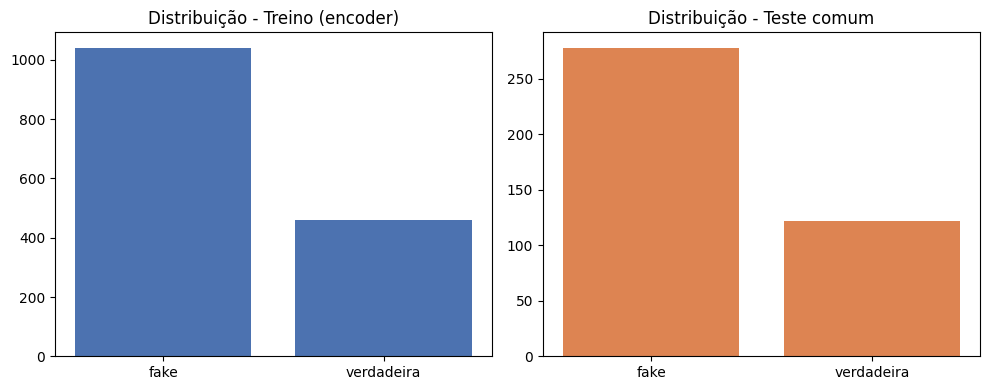

In [ ]:
DATASET_REPO = "kauandivino/FakenewsBR"
SUBSET_NAME = "default"

csv_path = hf_hub_download(
    repo_id=DATASET_REPO,
    filename="FakenewsBR_factchecked.csv",
    repo_type="dataset",
)
df = pd.read_csv(csv_path, dtype=str, low_memory=False).fillna("")

raw_dataset = DatasetDict({"train": Dataset.from_pandas(df)})
print(raw_dataset)
print("Colunas encontradas:", df.columns.tolist())

split_name = "train" if "train" in raw_dataset else list(raw_dataset.keys())[0]
print(raw_dataset[split_name].features)

# --- Padronizar nomes de coluna ---
TEXT_FALLBACK_CANDIDATES = ["text_clean", "text_no_url", "text", "content", "title"]
AVAILABLE_TEXT_COLS = [c for c in TEXT_FALLBACK_CANDIDATES if c in raw_dataset[split_name].column_names]
if not AVAILABLE_TEXT_COLS:
    raise ValueError(f"Nenhuma coluna textual esperada encontrada. Colunas: {raw_dataset[split_name].column_names}")
TEXT_COL_ORIGINAL = AVAILABLE_TEXT_COLS[0]

LABEL_COL_ORIGINAL = "label"
if LABEL_COL_ORIGINAL not in raw_dataset[split_name].column_names:
    raise ValueError(f"Coluna de rótulo 'label' não encontrada. Colunas: {raw_dataset[split_name].column_names}")

TEXT_COL = "text"
LABEL_COL = "label"
label_names = ["fake", "verdadeira"]
LABEL_TO_TEXT = {0: "fake", 1: "verdadeira"}

original_label_feature = raw_dataset[split_name].features[LABEL_COL_ORIGINAL]
original_label_names = getattr(original_label_feature, "names", None)
print("Rótulos originais:", original_label_names if original_label_names else "sem ClassLabel")

def normalize_fakenews_label(value):
    if original_label_names is not None and isinstance(value, int):
        text = str(original_label_names[value]).strip().lower()
    else:
        text = str(value).strip().lower()
    if text in {"0", "fake", "falsa", "false", "falso"}:
        return 0
    if text in {"1", "true", "verdadeira", "verdadeiro", "real"}:
        return 1
    raise ValueError(f"Rótulo não reconhecido: {value!r}")

def normalize_example(example):
    text = ""
    for col in AVAILABLE_TEXT_COLS:
        candidate = str(example.get(col, "") or "").strip()
        if candidate:
            text = candidate
            break
    return {
        TEXT_COL: text,
        LABEL_COL: normalize_fakenews_label(example[LABEL_COL_ORIGINAL]),
    }

# Forçamos o schema de saída explicitamente (label como int64) e desligamos o
# cache do .map(): sem isso, o datasets pode manter "label" como string em vez
# de inteiro, o que faz qualquer comparação ex[LABEL_COL] == 0/1 falhar sempre
# sem dar erro nenhum — foi essa a causa real do "0 exemplos para a classe fake".
output_features = Features({TEXT_COL: Value("string"), LABEL_COL: Value("int64")})

dataset = raw_dataset.map(
    normalize_example,
    remove_columns=raw_dataset[split_name].column_names,
    features=output_features,
    load_from_cache_file=False,
)
dataset = dataset.filter(lambda example: bool(example[TEXT_COL]), load_from_cache_file=False)

print("Colunas de texto usadas (em ordem de preferência):", AVAILABLE_TEXT_COLS)
print("Coluna de texto padronizada:", TEXT_COL)
print("Coluna de rótulo padronizada:", LABEL_COL)
print("Classes:", label_names)
print("Tipo real da coluna de rótulo:", dataset[split_name].features[LABEL_COL])

label_counts_after_clean = pd.Series([int(x) for x in dataset[split_name][LABEL_COL]]).value_counts().sort_index()
print("Distribuição de rótulos após limpeza de texto:",
      {label_names[i]: int(c) for i, c in label_counts_after_clean.items()})

# --- Construir os 3 splits da atividade ---
N_TRAIN = 1500
N_TEST = 400
N_FEWSHOT_PER_CLASS = 3

if "test" in dataset:
    train_source = dataset["train"].shuffle(seed=SEED)
    test_source = dataset["test"].shuffle(seed=SEED)
else:
    split = dataset[split_name].train_test_split(test_size=0.2, seed=SEED)
    train_source = split["train"].shuffle(seed=SEED)
    test_source = split["test"].shuffle(seed=SEED)

fewshot_rows = []
for class_idx, class_name in enumerate(label_names):
    class_subset = train_source.filter(lambda ex, lbl=class_idx: int(ex[LABEL_COL]) == lbl, load_from_cache_file=False)
    if len(class_subset) < N_FEWSHOT_PER_CLASS:
        raise ValueError(f"Poucos exemplos few-shot para a classe {class_name}: {len(class_subset)}")
    fewshot_rows.append(class_subset.select(range(N_FEWSHOT_PER_CLASS)).to_pandas())

fewshot_df = pd.concat(fewshot_rows).sample(frac=1, random_state=SEED).reset_index(drop=True)

fewshot_texts = set(fewshot_df[TEXT_COL])
train_pool = train_source.filter(lambda ex: ex[TEXT_COL] not in fewshot_texts, load_from_cache_file=False)

train_encoder = train_pool.select(range(min(N_TRAIN, len(train_pool))))
test_common = test_source.select(range(min(N_TEST, len(test_source))))

print(f"Treino (encoder): {len(train_encoder)} exemplos")
print(f"Teste comum: {len(test_common)} exemplos")
print(f"Few-shot: {len(fewshot_df)} exemplos")
print("\nExemplos de few-shot:")
display(fewshot_df[[TEXT_COL, LABEL_COL]])

length_df = pd.DataFrame({
    "split": ["train_encoder"] * len(train_encoder) + ["test_common"] * len(test_common),
    "text": list(train_encoder[TEXT_COL]) + list(test_common[TEXT_COL]),
})
length_df["chars"] = length_df["text"].astype(str).str.len()
length_df["words"] = length_df["text"].astype(str).str.split().str.len()
length_summary = length_df.groupby("split")[["chars", "words"]].describe(percentiles=[0.5, 0.9, 0.95, 0.99])
display(length_summary.round(1))
print("Maior texto em palavras:", int(length_df["words"].max()))

import matplotlib.pyplot as plt

train_counts = pd.Series(train_encoder[LABEL_COL]).value_counts().sort_index()
test_counts = pd.Series(test_common[LABEL_COL]).value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar([label_names[i] for i in train_counts.index], train_counts.values, color="#4C72B0")
axes[0].set_title("Distribuição - Treino (encoder)")
axes[1].bar([label_names[i] for i in test_counts.index], test_counts.values, color="#DD8452")
axes[1].set_title("Distribuição - Teste comum")
plt.tight_layout()
plt.show()


## 3. Loop de Fine-tuning dos Encoders

Cada encoder em `ENCODER_MODEL_NAMES` é carregado, treinado nos modos definidos por `FINETUNE_MODE`, avaliado e liberado da VRAM antes do próximo modelo.


In [ ]:
from transformers import (
    AutoTokenizer,
    AutoConfig,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
)

NUM_LABELS = len(label_names)


In [ ]:
def compute_metrics_encoder(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro"),
    }

def resolve_encoder_max_length(encoder_model_name, tokenizer):
    if isinstance(ENCODER_MAX_LENGTH, int):
        return ENCODER_MAX_LENGTH

    if ENCODER_MAX_LENGTH != "auto":
        raise ValueError('ENCODER_MAX_LENGTH deve ser "auto" ou um inteiro.')

    candidates = []
    tokenizer_limit = getattr(tokenizer, "model_max_length", None)
    if isinstance(tokenizer_limit, int) and 0 < tokenizer_limit < 100_000:
        candidates.append(tokenizer_limit)

    try:
        config = AutoConfig.from_pretrained(encoder_model_name)
        for attr in ["max_position_embeddings", "n_positions", "seq_length"]:
            value = getattr(config, attr, None)
            if isinstance(value, int) and value > 0:
                candidates.append(value)
    except Exception as exc:
        print(f"AVISO: não consegui ler AutoConfig para {encoder_model_name}: {exc}")

    if not candidates:
        print("AVISO: limite do modelo não encontrado; usando fallback 512.")
        resolved = 512
    else:
        resolved = min(candidates)

    if ENCODER_MAX_LENGTH_CAP is not None:
        resolved = min(resolved, int(ENCODER_MAX_LENGTH_CAP))

    return resolved

def encoder_batch_size_for_length(base_batch, max_length):
    if not ENCODER_DYNAMIC_BATCH_BY_LENGTH:
        return base_batch
    if max_length >= 4096:
        return min(base_batch, 1)
    if max_length >= 2048:
        return min(base_batch, 2)
    if max_length >= 1024:
        return min(base_batch, 4)
    return base_batch

def freeze_encoder_body_for_head_training(model):
    for param in model.parameters():
        param.requires_grad = False

    head_found = False
    for attr_name in ["classifier", "score", "classification_head"]:
        head = getattr(model, attr_name, None)
        if head is not None:
            for param in head.parameters():
                param.requires_grad = True
            head_found = True

    if not head_found:
        raise AttributeError(f"Não encontrei uma cabeça de classificação conhecida em {type(model).__name__}.")

def run_encoder_model(encoder_model_name):
    global encoder_tokenizer, train_tokenized, test_tokenized, data_collator

    print()
    print(f"{'#'*72}")
    print(f"ENCODER: {encoder_model_name}")
    print(f"{'#'*72}")
    print(f"VRAM antes de carregar: {current_vram_gb():.3f} GB")

    encoder_tokenizer = AutoTokenizer.from_pretrained(encoder_model_name)
    effective_encoder_max_length = resolve_encoder_max_length(encoder_model_name, encoder_tokenizer)
    print(f"Max length do encoder nesta execução: {effective_encoder_max_length}")

    def tokenize_function(examples):
        return encoder_tokenizer(
            examples[TEXT_COL],
            truncation=True,
            max_length=effective_encoder_max_length,
        )

    train_tokenized = train_encoder.map(tokenize_function, batched=True)
    test_tokenized = test_common.map(tokenize_function, batched=True)

    train_tokenized = train_tokenized.rename_column(LABEL_COL, "labels")
    test_tokenized = test_tokenized.rename_column(LABEL_COL, "labels")

    keep_cols = ["input_ids", "attention_mask", "labels"]
    train_tokenized = train_tokenized.remove_columns([c for c in train_tokenized.column_names if c not in keep_cols])
    test_tokenized = test_tokenized.remove_columns([c for c in test_tokenized.column_names if c not in keep_cols])

    data_collator = DataCollatorWithPadding(tokenizer=encoder_tokenizer)
    modes_to_run = ["full", "head", "lora"] if FINETUNE_MODE == "all" else [FINETUNE_MODE]
    model_results = []

    for mode_idx, mode in enumerate(modes_to_run):
        print()
        print(f"{'='*60}")
        print(f"  MODO: {mode} - {FINETUNE_CONFIG[mode]['label']}")
        print(f"{'='*60}")

        if mode_idx > 0:
            print(f"VRAM alocada ANTES do reset: {current_vram_gb():.3f} GB")
            release_model_memory(["base_model", "encoder_model", "trainer", "collated", "outputs"])
            print(f"VRAM alocada DEPOIS do reset: {current_vram_gb():.3f} GB")

        if mode == "lora":
            from peft import LoraConfig, get_peft_model, TaskType

        base_model = AutoModelForSequenceClassification.from_pretrained(
            encoder_model_name,
            num_labels=NUM_LABELS,
            torch_dtype=ENCODER_DTYPE,
        ).to(DEVICE)

        if hasattr(base_model, "gradient_checkpointing_enable"):
            base_model.gradient_checkpointing_enable()
            if hasattr(base_model.config, "use_cache"):
                base_model.config.use_cache = False

        if mode == "full":
            encoder_model = base_model
            print("Modo FULL: todos os pesos serão atualizados.")
        elif mode == "head":
            freeze_encoder_body_for_head_training(base_model)
            encoder_model = base_model
            trainable = sum(p.numel() for p in encoder_model.parameters() if p.requires_grad)
            total = sum(p.numel() for p in encoder_model.parameters())
            print(f"Modo HEAD: apenas {trainable:,} / {total:,} parâmetros treináveis ({100*trainable/total:.2f}%).")
        elif mode == "lora":
            target_modules = find_all_linear_names(base_model)
            print(f"LoRA target_modules detectados: {target_modules}")
            lora_config = LoraConfig(
                task_type=TaskType.SEQ_CLS,
                r=LORA_R,
                lora_alpha=LORA_ALPHA,
                lora_dropout=LORA_DROPOUT,
                target_modules=target_modules,
            )
            encoder_model = get_peft_model(base_model, lora_config)
            trainable = sum(p.numel() for p in encoder_model.parameters() if p.requires_grad)
            total = sum(p.numel() for p in encoder_model.parameters())
            print(f"Modo LORA: {trainable:,} / {total:,} parâmetros treináveis ({100*trainable/total:.2f}%).")

        cfg = FINETUNE_CONFIG[mode]
        train_batch_size = encoder_batch_size_for_length(cfg["batch"], effective_encoder_max_length)
        eval_batch_size = encoder_batch_size_for_length(ENCODER_EVAL_BATCH_SIZE, effective_encoder_max_length)
        print(
            f"Batch treino efetivo: {train_batch_size}; "
            f"batch avaliação efetivo: {eval_batch_size}; "
            f"grad_accum: {cfg.get('grad_accum', 1)}"
        )

        safe_model_name = re.sub(r"[^A-Za-z0-9_.-]+", "_", encoder_model_name)
        training_args = TrainingArguments(
            output_dir=f"./encoder_checkpoints_fakenews_{safe_model_name}_{mode}",
            learning_rate=cfg["lr"],
            num_train_epochs=cfg["epochs"],
            per_device_train_batch_size=train_batch_size,
            per_device_eval_batch_size=eval_batch_size,
            gradient_accumulation_steps=cfg.get("grad_accum", 1),
            eval_strategy="epoch",
            save_strategy="no",
            logging_steps=20,
            report_to="none",
            fp16=torch.cuda.is_available(),
            seed=SEED,
        )

        trainer = Trainer(
            model=encoder_model,
            args=training_args,
            train_dataset=train_tokenized,
            eval_dataset=test_tokenized,
            data_collator=data_collator,
            compute_metrics=compute_metrics_encoder,
        )

        try:
            train_result = trainer.train()
        except torch.cuda.OutOfMemoryError:
            print(
                "OOM durante o treino. A VRAM foi limpa; para este modelo/GPU, "
                "reduza ENCODER_MAX_LENGTH_CAP (ex.: 512), use FINETUNE_MODE='lora'/'head', "
                "ou remova modelos large/8k da lista."
            )
            release_model_memory(["trainer", "encoder_model", "base_model", "collated", "outputs"])
            raise
        print(train_result)

        reset_gpu_peak_memory()
        encoder_model.eval()
        all_preds = []
        all_labels = []
        batch_size = eval_batch_size
        start_time = time.time()

        with torch.no_grad():
            for i in range(0, len(test_tokenized), batch_size):
                batch = test_tokenized[i : i + batch_size]
                features = [
                    {"input_ids": batch["input_ids"][j], "attention_mask": batch["attention_mask"][j]}
                    for j in range(len(batch["input_ids"]))
                ]
                collated = data_collator(features)
                collated = {k: v.to(DEVICE) for k, v in collated.items()}

                outputs = encoder_model(**collated)
                preds = torch.argmax(outputs.logits, dim=-1).cpu().numpy()
                all_preds.extend(preds.tolist())
                all_labels.extend(batch["labels"])

        encoder_inference_time = time.time() - start_time
        encoder_peak_vram_gb = peak_vram_gb()
        encoder_accuracy = accuracy_score(all_labels, all_preds)
        encoder_f1 = f1_score(all_labels, all_preds, average="macro")

        print()
        print(f"--- Resultados ({encoder_model_name} | {FINETUNE_CONFIG[mode]['label']}) ---")
        print(f"Acurácia: {encoder_accuracy:.4f}")
        print(f"F1 (macro): {encoder_f1:.4f}")
        print(f"Tempo de inferência ({len(test_tokenized)} exemplos): {encoder_inference_time:.2f} s")
        print(f"Pico de VRAM durante a inferência: {encoder_peak_vram_gb:.3f} GB")
        print()
        print("Relatório de classificação:")
        print()
        print(classification_report(all_labels, all_preds, labels=list(range(NUM_LABELS)), target_names=label_names))

        encoder_result = {
            "run_id": RUN_ID,
            "timestamp": datetime.now().isoformat(timespec="seconds"),
            "papel": "encoder",
            "modelo": f"{encoder_model_name.split('/')[-1]} ({FINETUNE_CONFIG[mode]['label']})",
            "model_id": encoder_model_name,
            "dataset_repo": DATASET_REPO,
            "subset": SUBSET_NAME,
            "modo": mode,
            "n_train": len(train_encoder),
            "n_test": len(test_tokenized),
            "n_fewshot_por_classe": 0,
            "max_length": effective_encoder_max_length,
            "acuracia": encoder_accuracy,
            "f1_macro": encoder_f1,
            "tempo_inferencia_s": encoder_inference_time,
            "vram_pico_gb": encoder_peak_vram_gb,
            "tempo_por_exemplo_ms": (encoder_inference_time / len(test_tokenized)) * 1000,
            "saidas_invalidas": 0,
        }
        model_results.append(encoder_result)
        append_results_to_csv(encoder_result)

        del trainer
        del encoder_model
        del base_model
        if "outputs" in locals():
            del outputs
        if "collated" in locals():
            del collated
        gc.collect()
        reset_gpu_peak_memory()

    release_model_memory()
    return model_results

encoder_results_list = []

for encoder_idx, encoder_model_name in enumerate(ENCODER_MODEL_NAMES, start=1):
    print()
    print(f">>> Encoder {encoder_idx}/{len(ENCODER_MODEL_NAMES)}")
    release_model_memory()
    encoder_results_list.extend(run_encoder_model(encoder_model_name))
    print(f"VRAM após finalizar encoder: {current_vram_gb():.3f} GB")

encoder_results_df = pd.DataFrame(encoder_results_list).set_index("modelo")
encoder_results_df



>>> Encoder 1/10

########################################################################
ENCODER: amadeusai/JabuticaBERT-Large
########################################################################
VRAM antes de carregar: 0.000 GB


config.json:   0%|          | 0.00/861 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.26k [00:00<?, ?B/s]

spm.model: reconstructing file:   0%|          |  0.00B / 2.37MB            

spm.model: downloading bytes:           |  0.00B            

...

[transformers] BertForSequenceClassification LOAD REPORT from: google-bert/bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.

LoRA target_modules detectados: ['dense', 'key', 'query', 'value']
Modo LORA: 1,340,930 / 179,195,908 parâmetros treináveis (0.75%).
Batch treino efetivo: 8; batch avaliação efetivo: 8; grad_accum: 2


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,1.160299,0.573034,0.697500,0.433726
2,0.998830,0.557307,0.747500,0.652679
3,0.939789,0.534596,0.752500,0.654544


TrainOutput(global_step=282, training_loss=1.083368923647184, metrics={'train_runtime': 180.9988, 'train_samples_per_second': 24.862, 'train_steps_per_second': 1.558, 'total_flos': 937254232151520.0, 'train_loss': 1.083368923647184, 'epoch': 3.0})

--- Resultados (google-bert/bert-base-multilingual-cased | LoRA (r=8)) ---
Acurácia: 0.7525
F1 (macro): 0.6545
Tempo de inferência (400 exemplos): 3.98 s
Pico de VRAM durante a inferência: 0.835 GB

Relatório de classificação:

              precision    recall  f1-score   support

        fake       0.77      0.92      0.84       278
  verdadeira       0.68      0.36      0.47       122

    accuracy                           0.75       400
   macro avg       0.72      0.64      0.65       400
weighted avg       0.74      0.75      0.73       400

Resultados salvos em: /content/resultados_encoder_decoder_fakenews_ptbr_loop.csv
VRAM após finalizar encoder: 0.018 GB


,run_id,timestamp,papel,model_id,dataset_repo,subset,modo,n_train,n_test,n_fewshot_por_classe,max_length,acuracia,f1_macro,tempo_inferencia_s,vram_pico_gb,tempo_por_exemplo_ms,saidas_invalidas
modelo,,,,,,,,,,,,,,,,,
JabuticaBERT-Large (Full fine-tuning),20260723_153136,2026-07-23T15:49:01,encoder,amadeusai/JabuticaBERT-Large,kauandivino/FakenewsBR,default,full,1500,400,0,512,0.7125,0.658549,20.957407,6.176702,52.393519,0
JabuticaBERT-Large (Linear probing),20260723_153136,2026-07-23T16:13:57,encoder,amadeusai/JabuticaBERT-Large,kauandivino/FakenewsBR,default,head,1500,400,0,512,0.6950,0.410029,21.072401,2.389012,52.681003,0
JabuticaBERT-Large (LoRA (r=8)),20260723_153136,2026-07-23T16:32:20,encoder,amadeusai/JabuticaBERT-Large,kauandivino/FakenewsBR,default,lora,1500,400,0,512,0.6975,0.418765,25.346831,2.435026,63.367077,0
JabuticaBERT-XSmall (Full fine-tuning),20260723_153136,2026-07-23T16:35:22,encoder,amadeusai/JabuticaBERT-XSmall,kauandivino/FakenewsBR,default,full,1500,400,0,512,0.7575,0.668804,3.732507,1.087682,9.331268,0
JabuticaBERT-XSmall (Linear probing),20260723_153136,2026-07-23T16:39:45,encoder,amadeusai/JabuticaBERT-XSmall,kauandivino/FakenewsBR,default,head,1500,400,0,512,0.6950,0.410029,3.754602,0.507541,9.386505,0
JabuticaBERT-XSmall (LoRA (r=8)),20260723_153136,2026-07-23T16:43:23,encoder,amadeusai/JabuticaBERT-XSmall,kauandivino/FakenewsBR,default,lora,1500,400,0,512,0.6950,0.410029,4.678346,0.516265,11.695865,0
modernJabuticaBERT-Large-1k (Full fine-tuning),20260723_153136,2026-07-23T16:54:40,encoder,amadeusai/modernJabuticaBERT-Large-1k,kauandivino/FakenewsBR,default,full,1500,400,0,2048,0.8575,0.819779,10.971793,5.255189,27.429482,0
modernJabuticaBERT-Large-1k (Linear probing),20260723_153136,2026-07-23T17:08:25,encoder,amadeusai/modernJabuticaBERT-Large-1k,kauandivino/FakenewsBR,default,head,1500,400,0,2048,0.7850,0.711400,10.745800,1.661463,26.864501,0
modernJabuticaBERT-Large-1k (LoRA (r=8)),20260723_153136,2026-07-23T17:23:07,encoder,amadeusai/modernJabuticaBERT-Large-1k,kauandivino/FakenewsBR,default,lora,1500,400,0,2048,0.8275,0.780561,16.427419,1.757553,41.068547,0


## 5. Liberando a VRAM antes do Decoder

Depois do loop dos encoders, apagamos referências restantes e limpamos o cache CUDA antes de carregar os decoders.


In [ ]:
print(f"VRAM alocada após loop de encoders: {current_vram_gb():.3f} GB")
release_model_memory()
print(f"VRAM alocada antes do loop de decoders: {current_vram_gb():.3f} GB")


VRAM alocada após loop de encoders: 0.287 GB
VRAM alocada antes do loop de decoders: 0.287 GB


## 6. Few-Shot com os Decoders

Cada decoder em `DECODER_MODEL_NAMES` é carregado, avaliado no mesmo `test_common`, tem os resultados salvos no CSV e é removido da VRAM antes do próximo decoder.


In [ ]:
from transformers import AutoModelForCausalLM

decoder_results_list = []
decoder_previews = {}


### Montando o prompt de few-shot (via chat template)

A função abaixo monta uma lista de mensagens com:
1. Uma mensagem de **sistema** com a instrução da tarefa.
2. As mensagens de **few-shot**, alternando `user` (o comentário) e `assistant` (a classificação correta).
3. A mensagem final do **usuário**, com a frase do conjunto de teste a ser classificada.

O `apply_chat_template` converte essa lista de mensagens no formato textual exato que o Qwen2.5 espera (incluindo tokens especiais de início/fim de turno).

Ajuste o template livremente — esse é exatamente o tipo de experimentação que a atividade quer estimular (ver seção de Dicas Pedagógicas mais abaixo).

In [ ]:
# Nomes dos rótulos usados no prompt do decoder.
TEXT_TO_LABEL = {v: k for k, v in LABEL_TO_TEXT.items()}
LABEL_OPTIONS_TEXT = ", ".join([f"'{label}'" for label in LABEL_TO_TEXT.values()])

SYSTEM_PROMPT = (
    "Você é um classificador de notícias em português brasileiro. Sua única tarefa é "
    "responder exatamente uma das seguintes opções, sem explicação: "
    f"{LABEL_OPTIONS_TEXT}."
)

def prompt_text(text, max_chars=MAX_DECODER_TEXT_CHARS):
    text = str(text).replace("\n", " ").strip()
    if len(text) <= max_chars:
        return text
    return text[:max_chars].rsplit(" ", 1)[0] + " ..."

def build_fewshot_messages(target_sentence, fewshot_df, text_col=TEXT_COL, label_col=LABEL_COL):
    messages = [{"role": "system", "content": SYSTEM_PROMPT}]

    for _, row in fewshot_df.iterrows():
        label_text = LABEL_TO_TEXT[row[label_col]]
        messages.append({"role": "user", "content": f"Texto: {prompt_text(row[text_col])}"})
        messages.append({"role": "assistant", "content": label_text})

    messages.append({"role": "user", "content": f"Texto: {prompt_text(target_sentence)}"})
    return messages

def messages_to_plain_prompt(messages):
    parts = []
    for message in messages:
        role = message["role"]
        content = message["content"]
        if role == "system":
            parts.append(f"Instrução: {content}")
        elif role == "user":
            parts.append(f"Entrada: {content}")
        elif role == "assistant":
            parts.append(f"Resposta: {content}")
    parts.append("Resposta:")
    return "\n".join(parts)


### Função de limpeza da saída

O decoder não é obrigado a responder exatamente `"ofensivo"` ou `"não ofensivo"` — ele pode gerar variações como `"Ofensivo."`, `"é ofensivo"`, ou até frases mais longas. A função abaixo extrai a classe prevista de forma robusta, e marca como inválida (`None`) qualquer saída que não conseguirmos interpretar com segurança.

In [ ]:
def normalize_label_text(text):
    text = str(text).strip().lower()
    text = re.sub(r"[^\w\sãáàâéêíóôõúç-]", " ", text)
    text = re.sub(r"[_\s-]+", " ", text).strip()
    return text

NORMALIZED_LABEL_TO_ID = {
    normalize_label_text(label_text): label_id
    for label_id, label_text in LABEL_TO_TEXT.items()
}

for label_id, label_name in enumerate(label_names):
    NORMALIZED_LABEL_TO_ID.setdefault(normalize_label_text(label_name), label_id)

def parse_decoder_output(generated_text):
    """Extrai a classe prevista a partir do texto gerado pelo decoder."""
    normalized = normalize_label_text(generated_text.split("\n")[0])

    for label_text, label_id in sorted(NORMALIZED_LABEL_TO_ID.items(), key=lambda item: len(item[0]), reverse=True):
        if normalized == label_text or re.search(rf"\b{re.escape(label_text)}\b", normalized):
            return label_id
    return None

# Precisa bater com o max_new_tokens usado no .generate() lá embaixo.
GENERATION_MAX_NEW_TOKENS = 8

def resolve_decoder_max_length(decoder_model_name, tokenizer):
    """
    Alguns decoders (ex.: GPT-2) usam posições absolutas com limite rígido de
    contexto TOTAL (prompt + geração). Truncar o prompt em DECODER_MAX_LENGTH e
    ainda gerar mais max_new_tokens em cima disso pode passar do limite e travar
    a GPU com "CUDA error: device-side assert triggered". Aqui reservamos espaço
    pra geração e respeitamos o limite real do modelo, quando existir.
    """
    from transformers import AutoConfig

    candidates = [DECODER_MAX_LENGTH]
    tokenizer_limit = getattr(tokenizer, "model_max_length", None)
    if isinstance(tokenizer_limit, int) and 0 < tokenizer_limit < 1_000_000:
        candidates.append(tokenizer_limit)

    try:
        config = AutoConfig.from_pretrained(decoder_model_name)
        for attr in ["max_position_embeddings", "n_positions", "seq_length"]:
            value = getattr(config, attr, None)
            if isinstance(value, int) and value > 0:
                candidates.append(value)
    except Exception as exc:
        print(f"AVISO: não consegui ler AutoConfig para {decoder_model_name}: {exc}")

    model_limit = min(candidates)
    return max(1, model_limit - GENERATION_MAX_NEW_TOKENS)

def run_decoder_model(decoder_model_name):
    print()
    print(f"{'#'*72}")
    print(f"DECODER: {decoder_model_name}")
    print(f"{'#'*72}")
    print(f"VRAM antes de carregar: {current_vram_gb():.3f} GB")

    decoder_tokenizer = AutoTokenizer.from_pretrained(decoder_model_name)
    decoder_model = AutoModelForCausalLM.from_pretrained(
        decoder_model_name,
        torch_dtype=DECODER_DTYPE,
    ).to(DEVICE)
    decoder_model.eval()

    if decoder_tokenizer.pad_token is None:
        decoder_tokenizer.pad_token = decoder_tokenizer.eos_token

    has_chat_template = bool(getattr(decoder_tokenizer, "chat_template", None))
    effective_decoder_max_length = resolve_decoder_max_length(decoder_model_name, decoder_tokenizer)
    print("Decoder carregado:", decoder_model_name)
    print("Usa chat template:", has_chat_template)
    print(f"Max length efetivo (com espaço para {GENERATION_MAX_NEW_TOKENS} tokens gerados): {effective_decoder_max_length}")
    print(f"VRAM alocada após carregar o decoder: {current_vram_gb():.3f} GB")

    def tokenize_decoder_messages(messages):
        if has_chat_template:
            return decoder_tokenizer.apply_chat_template(
                messages,
                add_generation_prompt=True,
                tokenize=True,
                return_dict=True,
                return_tensors="pt",
                truncation=True,
                max_length=effective_decoder_max_length,
            ).to(DEVICE)

        prompt = messages_to_plain_prompt(messages)
        return decoder_tokenizer(
            prompt,
            return_tensors="pt",
            truncation=True,
            max_length=effective_decoder_max_length,
        ).to(DEVICE)

    example_messages = build_fewshot_messages(test_common[0][TEXT_COL], fewshot_df)
    if has_chat_template:
        example_prompt_text = decoder_tokenizer.apply_chat_template(
            example_messages, tokenize=False, add_generation_prompt=True
        )
    else:
        example_prompt_text = messages_to_plain_prompt(example_messages)
    print(example_prompt_text[:3000])

    fewshot_only_messages = example_messages[:-1]
    if has_chat_template:
        fewshot_tokens = len(decoder_tokenizer.apply_chat_template(
            fewshot_only_messages, tokenize=True, add_generation_prompt=False
        ))
    else:
        fewshot_tokens = len(decoder_tokenizer(messages_to_plain_prompt(fewshot_only_messages))["input_ids"])
    print(f"\nTokens do prompt few-shot (sem a pergunta): {fewshot_tokens}")
    print(f"Tokens disponíveis para pergunta + resposta: {effective_decoder_max_length - fewshot_tokens}")

    if fewshot_tokens > effective_decoder_max_length * 0.5:
        print("ALERTA: os exemplos few-shot ocupam mais de 50% do limite de tokens.")
        print("Reduza N_FEWSHOT_PER_CLASS ou encurte os exemplos para evitar truncamento.")
    if fewshot_tokens >= effective_decoder_max_length:
        raise RuntimeError(
            f"Prompt few-shot ({fewshot_tokens} tokens) excede o limite efetivo "
            f"({effective_decoder_max_length}) para {decoder_model_name}. "
            "Reduza N_FEWSHOT_PER_CLASS, encurte MAX_DECODER_TEXT_CHARS, ou pule este modelo."
        )

    reset_gpu_peak_memory()
    decoder_preds = []
    decoder_labels = []
    raw_outputs = []
    start_time = time.time()

    with torch.no_grad():
        for example in test_common:
            messages = build_fewshot_messages(example[TEXT_COL], fewshot_df)
            inputs = tokenize_decoder_messages(messages)

            output_ids = decoder_model.generate(
                **inputs,
                max_new_tokens=GENERATION_MAX_NEW_TOKENS,
                do_sample=False,
                pad_token_id=decoder_tokenizer.pad_token_id,
            )

            new_tokens = output_ids[0][inputs["input_ids"].shape[1]:]
            generated_text = decoder_tokenizer.decode(new_tokens, skip_special_tokens=True)

            pred_label = parse_decoder_output(generated_text)
            raw_outputs.append(generated_text)
            decoder_preds.append(pred_label)
            decoder_labels.append(example[LABEL_COL])

    decoder_inference_time = time.time() - start_time
    decoder_peak_vram_gb = peak_vram_gb()
    n_invalid = sum(1 for p in decoder_preds if p is None)

    print(f"Tempo total de inferência ({len(test_common)} exemplos): {decoder_inference_time:.2f} s")
    print(f"Pico de VRAM durante a inferência: {decoder_peak_vram_gb:.3f} GB")
    print(f"Saídas não interpretáveis: {n_invalid} de {len(decoder_preds)} ({n_invalid/len(decoder_preds)*100:.1f}%)")

    preview_size = min(10, len(test_common))
    preview_df = pd.DataFrame({
        "texto": [test_common[i][TEXT_COL] for i in range(preview_size)],
        "saida_bruta_decoder": raw_outputs[:preview_size],
        "classe_extraida": [decoder_preds[i] for i in range(preview_size)],
        "classe_real": [decoder_labels[i] for i in range(preview_size)],
    })
    decoder_previews[decoder_model_name] = preview_df
    display(preview_df)

    decoder_preds_clean = [
        p if p is not None else next(label for label in range(NUM_LABELS) if label != true_label)
        for p, true_label in zip(decoder_preds, decoder_labels)
    ]

    decoder_accuracy = accuracy_score(decoder_labels, decoder_preds_clean)
    decoder_f1 = f1_score(decoder_labels, decoder_preds_clean, average="macro")

    print(f"Acurácia: {decoder_accuracy:.4f}")
    print(f"F1 (macro): {decoder_f1:.4f}")
    print(f"Tempo de inferência (teste completo, {len(test_common)} exemplos): {decoder_inference_time:.2f} s")
    print(f"Pico de VRAM durante a inferência: {decoder_peak_vram_gb:.3f} GB")
    print("\nRelatório de classificação:\n")
    print(classification_report(decoder_labels, decoder_preds_clean, labels=list(range(NUM_LABELS)), target_names=label_names))

    decoder_result = {
        "run_id": RUN_ID,
        "timestamp": datetime.now().isoformat(timespec="seconds"),
        "papel": "decoder",
        "modelo": f"{decoder_model_name.split('/')[-1]} (decoder, few-shot)",
        "model_id": decoder_model_name,
        "dataset_repo": DATASET_REPO,
        "subset": SUBSET_NAME,
        "modo": "few-shot",
        "n_train": 0,
        "n_test": len(test_common),
        "n_fewshot_por_classe": N_FEWSHOT_PER_CLASS,
        "max_length": effective_decoder_max_length,
        "acuracia": decoder_accuracy,
        "f1_macro": decoder_f1,
        "tempo_inferencia_s": decoder_inference_time,
        "vram_pico_gb": decoder_peak_vram_gb,
        "tempo_por_exemplo_ms": (decoder_inference_time / len(test_common)) * 1000,
        "saidas_invalidas": n_invalid,
    }
    append_results_to_csv(decoder_result)

    del decoder_model
    del decoder_tokenizer
    release_model_memory(["inputs", "output_ids"])
    return decoder_result


> ⏳ **Nota de desempenho:** o loop acima roda exemplo a exemplo (`batch_size=1`) para simplificar o código didaticamente. Em ~400 exemplos com um modelo de 3B na T4, isso pode levar vários minutos — mais do que levaria com um decoder menor como o Tucano-1.1B. Se quiser acelerar, processe em batches fazendo *padding* à esquerda (`decoder_tokenizer.padding_side = "left"`) — fica como desafio extra opcional para a turma.

In [ ]:
for decoder_idx, decoder_model_name in enumerate(DECODER_MODEL_NAMES, start=1):
    print()
    print(f">>> Decoder {decoder_idx}/{len(DECODER_MODEL_NAMES)}")
    release_model_memory()
    decoder_results_list.append(run_decoder_model(decoder_model_name))
    print(f"VRAM após finalizar decoder: {current_vram_gb():.3f} GB")

decoder_results_df = pd.DataFrame(decoder_results_list).set_index("modelo")
decoder_results_df



>>> Decoder 1/8

########################################################################
DECODER: amadeusai/Amadeus-Verbo-FI-Qwen2.5-0.5B-PT-BR-Instruct
########################################################################
VRAM antes de carregar: 0.287 GB


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Decoder carregado: amadeusai/Amadeus-Verbo-FI-Qwen2.5-0.5B-PT-BR-Instruct
Usa chat template: True
Max length efetivo (com espaço para 8 tokens gerados): 1016
VRAM alocada após carregar o decoder: 1.220 GB
<|im_start|>system
Você é um classificador de notícias em português brasileiro. Sua única tarefa é responder exatamente uma das seguintes opções, sem explicação: 'fake', 'verdadeira'.<|im_end|>
<|im_start|>user
Texto: manifestacao pacifica e democratica do pt, psol, cut… #sqn.<|im_end|>
<|im_start|>assistant
fake<|im_end|>
<|im_start|>user
Texto: filho de bolsonaro ofende nordestinos em video<|im_end|>
<|im_start|>assistant
fake<|im_end|>
<|im_start|>user
Texto: e-mails entregues por marcelo odebrecht em processo contra lula sao autenticos, diz pf. segundo a defesa do empresario, mensagens reforcam o que marcelo afirmou na delacao premiada a respeito da compra, pela odebrecht, do terreno que abrigaria a sede do instituto lula.. um laudo divulgado pela policia federal (pf) nesta terca-

,texto,saida_bruta_decoder,classe_extraida,classe_real
0,repassem este texto para a populacao ordeira s...,avam sendo dadas ao público sobre,NaN,0
1,*juiz federal bloqueia dinheiro dos fundos par...,fake,0.0,1
2,medidas impopulares: governo podera taxar igre...,á que os políticos possam usar,NaN,0
3,23 senadores investigados na lava jato ficam s...,tribunal. A decisão foi tomada pelo,NaN,1
4,boa noite. meus amigos a luta continua. nao de...,aos nossos trabalhadores e a,NaN,1
5,quem for esta viajando dia 28 pessoal espalhem...,dias 29 e 30,NaN,1
6,partido militar podera lancar coronel telhada ...,mente está em busca de um cargo na,NaN,0
7,dpa se chamar “fatima” num pais avesso ao que ...,uma religiao de grande importância. A,NaN,1
8,"coronavirus: china voltou a confinar ""milhoes""...",fake,0.0,0
9,e impressionante como familia pixuleco da silv...,"ertura de chumbo, etc. e",NaN,0


Acurácia: 0.2900
F1 (macro): 0.2634
Tempo de inferência (teste completo, 400 exemplos): 172.36 s
Pico de VRAM durante a inferência: 1.380 GB

Relatório de classificação:

              precision    recall  f1-score   support

        fake       0.48      0.35      0.40       278
  verdadeira       0.10      0.16      0.12       122

    accuracy                           0.29       400
   macro avg       0.29      0.25      0.26       400
weighted avg       0.37      0.29      0.32       400

Resultados salvos em: /content/resultados_encoder_decoder_fakenews_ptbr_loop.csv
VRAM após finalizar decoder: 0.287 GB

>>> Decoder 2/8

########################################################################
DECODER: amadeusai/Amadeus-Verbo-FI-Qwen2.5-1.5B-PT-BR-Instruct
########################################################################
VRAM antes de carregar: 0.287 GB


...

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Decoder carregado: Qwen/Qwen2.5-1.5B-Instruct
Usa chat template: True
Max length efetivo (com espaço para 8 tokens gerados): 1016
VRAM alocada após carregar o decoder: 3.165 GB
<|im_start|>system
Você é um classificador de notícias em português brasileiro. Sua única tarefa é responder exatamente uma das seguintes opções, sem explicação: 'fake', 'verdadeira'.<|im_end|>
<|im_start|>user
Texto: manifestacao pacifica e democratica do pt, psol, cut… #sqn.<|im_end|>
<|im_start|>assistant
fake<|im_end|>
<|im_start|>user
Texto: filho de bolsonaro ofende nordestinos em video<|im_end|>
<|im_start|>assistant
fake<|im_end|>
<|im_start|>user
Texto: e-mails entregues por marcelo odebrecht em processo contra lula sao autenticos, diz pf. segundo a defesa do empresario, mensagens reforcam o que marcelo afirmou na delacao premiada a respeito da compra, pela odebrecht, do terreno que abrigaria a sede do instituto lula.. um laudo divulgado pela policia federal (pf) nesta terca-feira (27) aponta que sao au

,texto,saida_bruta_decoder,classe_extraida,classe_real
0,repassem este texto para a populacao ordeira s...,avam sendo publicadas pelo jornal,NaN,0
1,*juiz federal bloqueia dinheiro dos fundos par...,fake,0.0,1
2,medidas impopulares: governo podera taxar igre...,anunciou hoje que vai exigir que,NaN,0
3,23 senadores investigados na lava jato ficam s...,"tribunal federativo (stf), mas",NaN,1
4,boa noite. meus amigos a luta continua. nao de...,a vida e a esperança. vamos,NaN,1
5,quem for esta viajando dia 28 pessoal espalhem...,votantes em casa.,NaN,1
6,partido militar podera lancar coronel telhada ...,mente faz parte do grupo de lideranca,NaN,0
7,dpa se chamar “fatima” num pais avesso ao que ...,"algo estranho, não pode ser",NaN,1
8,"coronavirus: china voltou a confinar ""milhoes""...",fake,0.0,0
9,e impressionante como familia pixuleco da silv...,"ertura de luxo, casa de alto",NaN,0


Acurácia: 0.4050
F1 (macro): 0.2883
Tempo de inferência (teste completo, 400 exemplos): 194.57 s
Pico de VRAM durante a inferência: 3.340 GB

Relatório de classificação:

              precision    recall  f1-score   support

        fake       0.57      0.58      0.58       278
  verdadeira       0.00      0.00      0.00       122

    accuracy                           0.41       400
   macro avg       0.29      0.29      0.29       400
weighted avg       0.40      0.41      0.40       400

Resultados salvos em: /content/resultados_encoder_decoder_fakenews_ptbr_loop.csv
VRAM após finalizar decoder: 0.287 GB


,run_id,timestamp,papel,model_id,dataset_repo,subset,modo,n_train,n_test,n_fewshot_por_classe,max_length,acuracia,f1_macro,tempo_inferencia_s,vram_pico_gb,tempo_por_exemplo_ms,saidas_invalidas
modelo,,,,,,,,,,,,,,,,,
"Amadeus-Verbo-FI-Qwen2.5-0.5B-PT-BR-Instruct (decoder, few-shot)",20260723_231214,2026-07-23T23:16:12,decoder,amadeusai/Amadeus-Verbo-FI-Qwen2.5-0.5B-PT-BR-...,kauandivino/FakenewsBR,default,few-shot,0,400,3,1016,0.2900,0.263409,172.356908,1.380023,430.892270,197
"Amadeus-Verbo-FI-Qwen2.5-1.5B-PT-BR-Instruct (decoder, few-shot)",20260723_231214,2026-07-23T23:19:50,decoder,amadeusai/Amadeus-Verbo-FI-Qwen2.5-1.5B-PT-BR-...,kauandivino/FakenewsBR,default,few-shot,0,400,3,1016,0.4000,0.285714,195.925887,3.339730,489.814718,197
"gpt2-small-portuguese (decoder, few-shot)",20260723_231214,2026-07-23T23:20:32,decoder,pierreguillou/gpt2-small-portuguese,kauandivino/FakenewsBR,default,few-shot,0,400,3,1016,0.2025,0.173441,37.501597,0.603199,93.753994,108
"Qwen2.5-0.5B-Instruct (decoder, few-shot)",20260723_231214,2026-07-23T23:22:59,decoder,Qwen/Qwen2.5-0.5B-Instruct,kauandivino/FakenewsBR,default,few-shot,0,400,3,1016,0.1275,0.122890,140.465057,1.380023,351.162642,197
"Tucano2-qwen-0.5B-Instruct (decoder, few-shot)",20260723_231214,2026-07-23T23:25:47,decoder,Polygl0t/Tucano2-qwen-0.5B-Instruct,kauandivino/FakenewsBR,default,few-shot,0,400,3,1016,0.0175,0.017199,161.363666,1.506455,403.409165,387
"Tucano2-qwen-1.5B-Instruct (decoder, few-shot)",20260723_231214,2026-07-23T23:39:26,decoder,Polygl0t/Tucano2-qwen-1.5B-Instruct,kauandivino/FakenewsBR,default,few-shot,0,400,3,1016,0.0100,0.009901,648.318679,3.303902,1620.796698,391
"mGPT (decoder, few-shot)",20260723_231214,2026-07-23T23:45:12,decoder,ai-forever/mGPT,kauandivino/FakenewsBR,default,few-shot,0,400,3,1016,0.0000,0.000000,142.756778,3.201062,356.891946,400
"Qwen2.5-1.5B-Instruct (decoder, few-shot)",20260723_231214,2026-07-23T23:52:01,decoder,Qwen/Qwen2.5-1.5B-Instruct,kauandivino/FakenewsBR,default,few-shot,0,400,3,1016,0.4050,0.288256,194.565387,3.339730,486.413466,194


## 7. Comparação Final

Agora juntamos as métricas de todos os modos de fine-tuning do encoder com o decoder em uma única tabela e gráfico comparativo.

In [ ]:
all_rows = encoder_results_list + decoder_results_list
comparison_df = pd.DataFrame(all_rows).set_index("modelo")
comparison_df = comparison_df.rename(columns={
    "acuracia": "Acurácia",
    "f1_macro": "F1 (macro)",
    "tempo_inferencia_s": "Tempo total (s)",
    "vram_pico_gb": "Pico VRAM (GB)",
    "tempo_por_exemplo_ms": "Tempo / exemplo (ms)",
})

display(comparison_df.round(4))
comparison_df.round(4).to_csv("comparacao_ultima_execucao_fakenews_loop.csv")
print("Resumo da última execução salvo em: comparacao_ultima_execucao_fakenews_loop.csv")
print(f"Histórico acumulado salvo em: {RESULTS_CSV_PATH}")

COLOR_MAP = {"full": "#4C72B0", "head": "#55A868", "lora": "#DD8452", "few-shot": "#C44E52", "decoder": "#C44E52"}
bar_colors = [COLOR_MAP.get(row.get("modo", "few-shot"), "#333333") for row in all_rows]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
metrics_to_plot = [
    ("Acurácia", axes[0, 0]),
    ("F1 (macro)", axes[0, 1]),
    ("Tempo total (s)", axes[1, 0]),
    ("Pico VRAM (GB)", axes[1, 1]),
]

for metric_name, ax in metrics_to_plot:
    ax.bar(comparison_df.index, comparison_df[metric_name], color=bar_colors)
    ax.set_title(metric_name)
    ax.tick_params(axis="x", rotation=70)

plt.tight_layout()
plt.savefig("comparacao_encoder_decoder_fakenews_loop.png", dpi=150)
plt.show()


NameError: name 'encoder_results_list' is not defined

## 8. Discussão (para responder em texto)

Use os resultados acima para responder, com suas próprias palavras:

1. **Acurácia/F1:** qual modelo teve melhor desempenho na classificação de fake news? O fine-tuning do encoder superou o few-shot do decoder?
2. **Tempo de inferência:** qual modelo foi mais rápido por exemplo? Relacione isso ao funcionamento de encoders e decoders autoregressivos.
3. **VRAM:** por que o decoder pode consumir mais memória mesmo sem treinamento?
4. **Qualidade das saídas do decoder:** quantos exemplos tiveram saída não interpretável? O modelo respeitou os rótulos `fake` e `verdadeira`?
5. **Limitações:** uma classificação de fake news baseada apenas no texto pode capturar estilo e domínio do dataset, mas não verifica fatos no mundo real. Como isso afeta a interpretação dos resultados?

---

### Dica para ir além (opcional)
- Salve as respostas brutas do decoder em um CSV separado para inspecionar erros qualitativamente.
- Teste `ENCODER_MAX_LENGTH = 512` para verificar se notícias mais longas melhoram o desempenho do encoder.
- Compare um decoder PT-BR com um decoder multilíngue pequeno para observar diferenças de idioma nas respostas.
